In [ ]:
#title : 'Do older planes suffer more delays?
#author : Vishma Arachchi
#date : 2024-02-06
#purpose : A script to explore the relationship between plane age and corresponding delay times.


In [1]:
#IMPORTING LIBRARIES

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
#Downloading the datasets

df_main = pd.read_csv("/Users/vishmaarachchi/Documents/BSC/Programming coursework - PROJECT/2006.csv.bz2")
plane_data = pd.read_csv('/Users/vishmaarachchi/Documents/BSC/Programming coursework - PROJECT/plane-data.csv')



In [3]:
#Renaming the year column to Year of commencement of service

plane_data.rename(columns={'year': 'Start_of_Service'}, inplace=True)
plane_data.rename(columns={'tailnum': 'TailNum'}, inplace=True)
df_main.rename(columns={'Year': 'Year_of_Record'}, inplace=True)


In [4]:
#Dropping planes with year of commencement = 0

plane_data = plane_data.drop(plane_data[plane_data['Start_of_Service'] == 0].index)

In [5]:
#dropping rows where the year of commencement of services is NA, as these rows are of no use
#in calculating age of the plane

plane_data.dropna(subset=['Start_of_Service'], inplace=True)


In [6]:
#Donverting start of service columnn to integar

plane_data['Start_of_Service'] = plane_data['Start_of_Service'].astype(int)

In [7]:
#Checking null values

df_main.isnull().sum()

Year_of_Record             0
Month                      0
DayofMonth                 0
DayOfWeek                  0
DepTime               121934
CRSDepTime                 0
ArrTime               138120
CRSArrTime                 0
UniqueCarrier              0
FlightNum                  0
TailNum                    0
ActualElapsedTime     138120
CRSElapsedTime             4
AirTime               138120
ArrDelay              138120
DepDelay              121934
Origin                     0
Dest                       0
Distance                   0
TaxiIn                     0
TaxiOut                    0
Cancelled                  0
CancellationCode     7019988
Diverted                   0
CarrierDelay               0
WeatherDelay               0
NASDelay                   0
SecurityDelay              0
LateAircraftDelay          0
dtype: int64

In [8]:
#Filling of null values in Arr Delay and Dep delay columns

Arrival_delay_mean = df_main['ArrDelay'].mean()
df_main['ArrDelay'] = df_main['ArrDelay'].fillna(Arrival_delay_mean)


Departure_delay_mean = df_main['DepDelay'].mean()
df_main['DepDelay'] = df_main['DepDelay'].fillna(Departure_delay_mean)


In [9]:
df_main.isnull().sum()

Year_of_Record             0
Month                      0
DayofMonth                 0
DayOfWeek                  0
DepTime               121934
CRSDepTime                 0
ArrTime               138120
CRSArrTime                 0
UniqueCarrier              0
FlightNum                  0
TailNum                    0
ActualElapsedTime     138120
CRSElapsedTime             4
AirTime               138120
ArrDelay                   0
DepDelay                   0
Origin                     0
Dest                       0
Distance                   0
TaxiIn                     0
TaxiOut                    0
Cancelled                  0
CancellationCode     7019988
Diverted                   0
CarrierDelay               0
WeatherDelay               0
NASDelay                   0
SecurityDelay              0
LateAircraftDelay          0
dtype: int64

In [10]:
#CHECKING CORRELATION BETWEEN ARRIVAL DELAY AND DEPARTURE DELAY(VERY HIGH CO-EFFITIENT)

correlation_coefficient = df_main['ArrDelay'].corr(df_main['DepDelay'])
print(correlation_coefficient)

0.915451502845212


In [11]:
#creating a new column for total delays in the main dataframe 

df_main['Total_Delays'] = df_main['ArrDelay'] + df_main['DepDelay']

In [12]:
#Merging plane data and the main dataset on TailNumber column


dff_1 = pd.merge(df_main, plane_data, on='TailNum', how='left')

In [13]:
#Dropping start of service = NA rows. These cannot be used to calculate the age of the plane

dff_1.dropna(subset=['Start_of_Service'], inplace=True)


#converting start of service columnn to integar

dff_1['Start_of_Service'] = dff_1['Start_of_Service'].astype(int)

In [14]:
#New dataframe with rows consisting of only the rows where a delay occurs

only_delays = dff_1.loc[dff_1.Total_Delays > 0]


In [15]:
#New dataframe with year of record/Start of service year/Total delays columns

dff_2 = only_delays.iloc[:,[0,37,29,]]


In [16]:
#Creating new column for the age of the plane as of the year being recorded

dff_2['Age'] = dff_2['Year_of_Record']-dff_2['Start_of_Service']

/var/folders/yp/w9t80bwn7wq66cg1_srgxg3h0000gn/T/ipykernel_17873/3171210800.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff_2['Age'] = dff_2['Year_of_Record']-dff_2['Start_of_Service']


In [17]:
#Unique values for age

dff_2['Age'].unique()

array([ 7, 17,  8,  6, 19,  9, 16,  5, 18,  4, 22,  1, 21, 14, 12,  2,  3,
       11, 20, 15, 10, 13, 40,  0, 49, 30, 37, 31, 38, 35, 39, 27, 26, 28,
       36, 29, 33, 34, -1, 32, 50, 43, 23, 24, 47, 44, 42, 41])

In [18]:
#removing rows where age of plane is = -1

dff_2 = dff_2[dff_2['Age'] != -1]

In [19]:
#converting the dataframe to long and then wide format so as to get the average delays for each age of the plane 


dff_2_long = pd.melt(dff_2, id_vars = ['Age'],  value_vars = ['Total_Delays'])

dff_2_wide = dff_2_long.pivot_table(values='value', index=['Age'], columns=['variable'],aggfunc = np.mean)

dff_2_wide.reset_index(inplace=True)

dff_2_wide = dff_2_wide.rename(columns={'Total_Delays': 'Average_Delay'})

dff_2_wide

variable,Age,Average_Delay
0,0,59.833927
1,1,58.209870
2,2,57.819611
3,3,57.836683
4,4,58.032719
5,5,54.805064
6,6,57.327979
7,7,57.192940
8,8,56.122634
9,9,64.263239


Text(0, 0.5, 'Average Delays(min)')

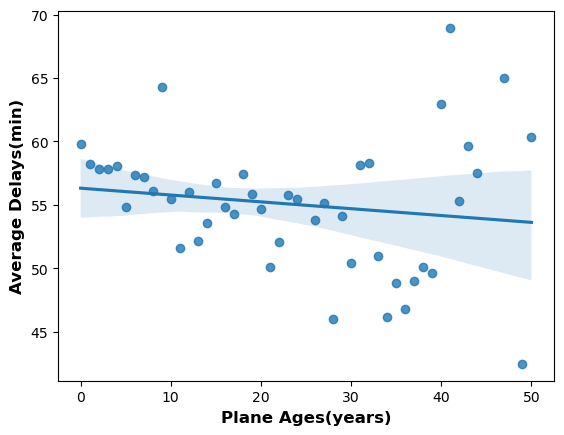

In [20]:
#Plotting the relationship between plane age and Average delay

fig, ax = plt.subplots()


ax1 = sns.regplot(x = 'Age', y = 'Average_Delay', data = dff_2_wide)
ax1.set_xlabel("Plane Ages(years)", fontdict={"weight": "bold", "fontsize": 12})
ax1.set_ylabel("Average Delays(min)", fontdict={"weight": "bold", "fontsize": 12})


In [21]:
#The correlation coeffitient between age and Average delay

correlation_coefficient = dff_2_wide['Age'].corr(dff_2_wide['Average_Delay'])
print(correlation_coefficient)

-0.15201710402964563


In [22]:
#Drawing a boxplot with ages categorized into classes


values_to_be_mapped_1 = [0,1,2,3,4,5,6,7,8,9,10,11]
values_to_be_mapped_2 = [12,13,14,15,16,17,18,19,20,21]
values_to_be_mapped_3 = [22,23,24,25,26,27,28,29,30,31]
values_to_be_mapped_4 = [32,33,34,35,36,37,38,39,40,41]
values_to_be_mapped_5 = [42,43,44,45,46,47,48,49,50,51]

replacement_value_1 = '0-11'
replacement_value_2 = '12-21'
replacement_value_3 = '22-31'
replacement_value_4 = '32-41'
replacement_value_5 = '42-51'


values_to_be_mapped_list = [values_to_be_mapped_1,values_to_be_mapped_2, values_to_be_mapped_3 ,values_to_be_mapped_4 ,values_to_be_mapped_5]
replacement_value_list = [replacement_value_1,replacement_value_2,replacement_value_3,replacement_value_4,replacement_value_5]

dff_2['Age_groups'] = dff_2['Age'].replace(values_to_be_mapped_list, replacement_value_list)

Text(0, 0.5, 'Total Delay')

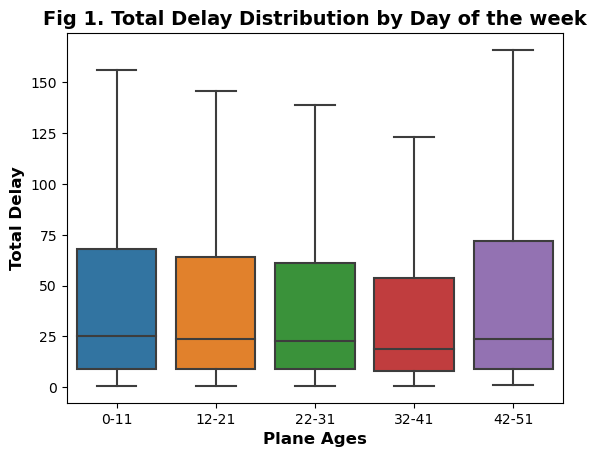

In [23]:
fig, ax = plt.subplots()

box_plot_labels_1 = ['0-11','12-21','22-31','32-41','42-51']

ax1 = sns.boxplot(x="Age_groups", y="Total_Delays", data=dff_2, showfliers = False )
ax1.set_title("Fig 1. Total Delay Distribution by Day of the week", fontdict={"weight": "bold", "fontsize": 14})
ax1.set_xlabel("Plane Ages", fontdict={"weight": "bold", "fontsize": 12})
ax1.set_ylabel("Total Delay", fontdict={"weight": "bold", "fontsize": 12})

